# Minería de Datos sobre Capa Oro



## Importar las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

MINERIA_DIR = Path('../data/mineria')
MINERIA_DIR.mkdir(parents=True, exist_ok=True)

print("Librerías importadas.")

Librerías importadas.


## Carga de datos

Cargamos los datasets generados en la **Capa Oro**.

In [ ]:
file_diario = '../data/oro/dataset_oro_diario.csv'
file_horario = '../data/oro/dataset_oro.csv'


df_diario = pd.read_csv(file_diario)
df_base = pd.read_csv(file_horario)
print(f"Datos cargados. Diario: {df_diario.shape}, Horario: {df_base.shape}")


Datos cargados. Diario: (1092, 37), Horario: (106386, 31)


## Generación de la variable objetivo: `ALERTA_BATERIA`

En sistemas aislados (off-grid), una descarga profunda acorta la vida útil de las baterías. Definiremos una alerta heurística:

- **1 (Alerta Crítica)** si el SOC promedio (`battery_soc_%`) < 70% **O** el voltaje mínimo del día (`battery_voltage_V_MIN`) < 11.0V.
- **0 (Operación Normal)** en caso contrario.

In [3]:
df_diario.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   station_name                    1092 non-null   str    
 1   fecha                           1092 non-null   str    
 2   pv_voltage_V_NORM_MEAN          1092 non-null   float64
 3   pv_voltage_V_NORM_MIN           1092 non-null   float64
 4   pv_voltage_V_NORM_MAX           1092 non-null   float64
 5   pv_current_A_NORM_MEAN          1092 non-null   float64
 6   pv_current_A_NORM_MIN           1092 non-null   float64
 7   pv_current_A_NORM_MAX           1092 non-null   float64
 8   pv_power_W_NORM_MEAN            1092 non-null   float64
 9   pv_power_W_NORM_MIN             1092 non-null   float64
 10  pv_power_W_NORM_MAX             1092 non-null   float64
 11  battery_soc_%_NORM_MEAN         1092 non-null   float64
 12  battery_soc_%_NORM_MIN          1092 non-null

In [22]:
if not df_diario.empty:
    # Definir umbrales
    soc_minimo = 0.7
    voltaje_critico = 0.75
    corriente_critica = 0.8
    
    # Crear variable binaria
    df_diario['ALERTA_BATERIA'] = ((df_diario['battery_soc_%_NORM_MIN'] < soc_minimo) | 
                                   (df_diario['battery_voltage_V_NORM_MIN'] < voltaje_critico) |
                                   (df_diario['battery_current_A_NORM_MEAN'] > voltaje_critico)).astype(int)
    
    # Guardar en la carpeta de minería
    df_diario.to_csv(MINERIA_DIR / 'dataset_mineria_diario.csv', index=False)
    print("Variable ALERTA_BATERIA generada y dataset guardado.")


Variable ALERTA_BATERIA generada y dataset guardado.


## Exploración de la variable `ALERTA_BATERIA`

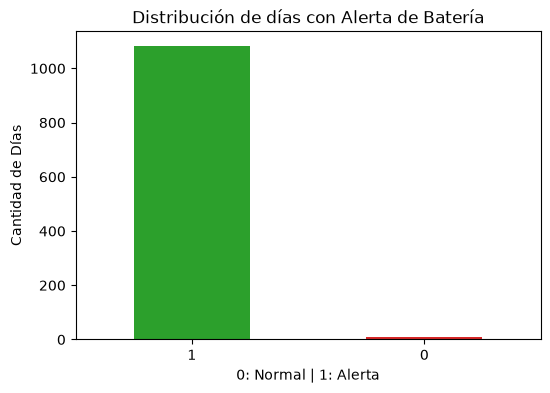

In [23]:
if not df_diario.empty:
    plt.figure(figsize=(6,4))
    df_diario['ALERTA_BATERIA'].value_counts().plot(kind='bar', color=['#2ca02c', '#d62728'])
    plt.title("Distribución de días con Alerta de Batería")
    plt.xlabel("0: Normal | 1: Alerta")
    plt.ylabel("Cantidad de Días")
    plt.xticks(rotation=0)
    plt.show()


### Heatmap de Correlación General
Buscamos entender qué factores operacionales correlacionan más con nuestra variable de alerta.

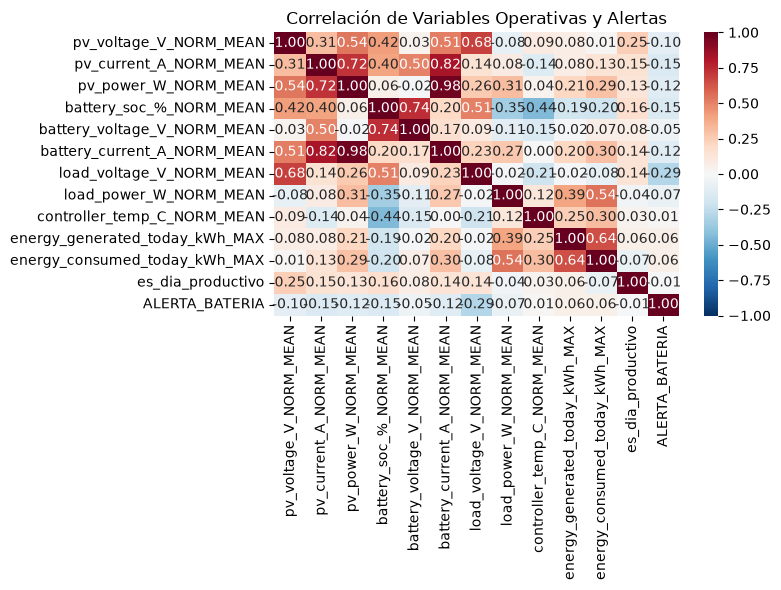

In [24]:
if not df_diario.empty:
    # Variables relevantes
    vars_corr = [
        'pv_voltage_V_NORM_MEAN','pv_current_A_NORM_MEAN', 'pv_power_W_NORM_MEAN', 'battery_soc_%_NORM_MEAN',
        'battery_voltage_V_NORM_MEAN', 'battery_current_A_NORM_MEAN', 'load_voltage_V_NORM_MEAN', 'load_current_A_NORM_MEAN ', 
        'load_power_W_NORM_MEAN', 'controller_temp_C_NORM_MEAN', 'energy_generated_today_kWh_MAX', 
        'energy_consumed_today_kWh_MAX', 'es_dia_productivo', 'ALERTA_BATERIA'
    ]
    
    # Filtrar columnas que sí existan en el df
    vars_corr = [v for v in vars_corr if v in df_diario.columns]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(df_diario[vars_corr].corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlación de Variables Operativas y Alertas")
    plt.tight_layout()
    plt.show()


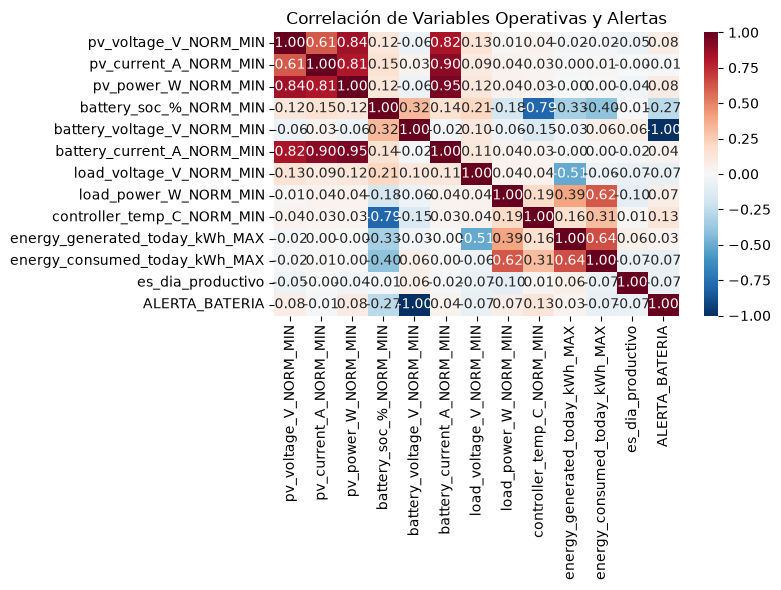

In [16]:
if not df_diario.empty:
    # Variables relevantes
    vars_corr = [
        'pv_voltage_V_NORM_MIN','pv_current_A_NORM_MIN', 'pv_power_W_NORM_MIN', 'battery_soc_%_NORM_MIN',
        'battery_voltage_V_NORM_MIN', 'battery_current_A_NORM_MIN', 'load_voltage_V_NORM_MIN', 'load_current_A_NORM_MIN ', 
        'load_power_W_NORM_MIN', 'controller_temp_C_NORM_MIN', 'energy_generated_today_kWh_MAX', 
        'energy_consumed_today_kWh_MAX', 'es_dia_productivo', 'ALERTA_BATERIA'
    ]
    
    # Filtrar columnas que sí existan en el df
    vars_corr = [v for v in vars_corr if v in df_diario.columns]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(df_diario[vars_corr].corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlación de Variables Operativas y Alertas")
    plt.tight_layout()
    plt.show()

## Clustering de Días Operativos (K-Means)

Se aplica **K-Means** para agrupar días según su comportamiento. Esto nos permite identificar perfiles como "Día de alta carga y mucho sol" vs "Día nublado y batería baja".

In [31]:
if not df_diario.empty:
    # Seleccionamos variables de trabajo
    cols_clust = ['pv_power_W_NORM_MEAN', 'battery_soc_%_NORM_MEAN', 'battery_voltage_RANGE']
    cols_clust = [c for c in cols_clust if c in df_diario.columns]
    
    X_clust = df_diario[cols_clust].dropna()
    
    # Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clust)
    
    # Aplicar K-Means (elegimos 3 clusters como ejemplo de perfiles diarios)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    df_diario.loc[X_clust.index, 'CLUSTER'] = kmeans.fit_predict(X_scaled)
    
    print("Distribución de días por Cluster:")
    print(df_diario['CLUSTER'].value_counts())


Distribución de días por Cluster:
CLUSTER
0.0    954
1.0    138
Name: count, dtype: int64


### Visualización con PCA
Para entender los clústeres, reducimos la dimensionalidad a 2 dimensiones (Componentes Principales).

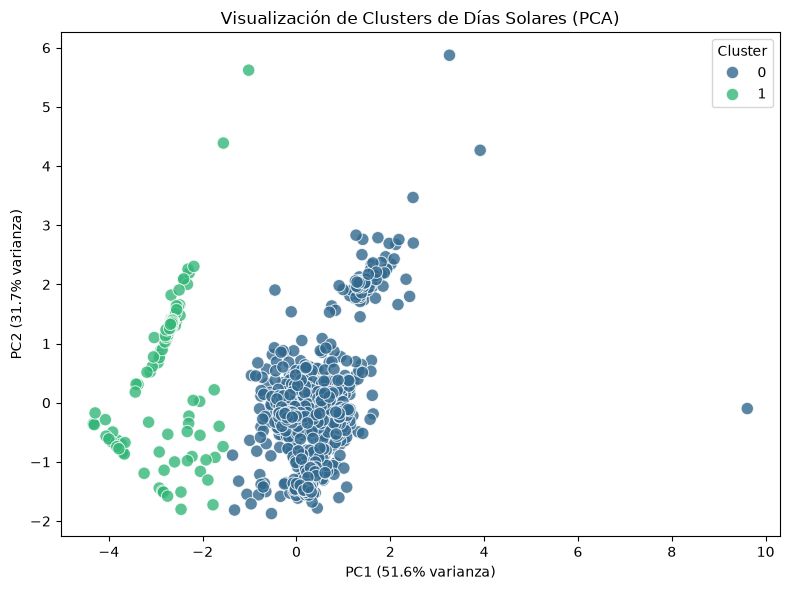

In [32]:
if not df_diario.empty:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['Cluster'] = kmeans.labels_
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=80, alpha=0.8)
    plt.title("Visualización de Clusters de Días Solares (PCA)")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)")
    plt.tight_layout()
    plt.show()


### Interpretación de los Clusters (K-Means)
Calculamos la media de las variables por cada clúster para etiquetarlos conceptualmente.

In [33]:
if not df_diario.empty:
    perfiles = df_diario.groupby('CLUSTER')[cols_clust].mean().round(2)
    display(perfiles)


,pv_power_W_NORM_MEAN,battery_soc_%_NORM_MEAN,battery_voltage_RANGE
CLUSTER,,,
0.0,0.10,0.64,0.13
1.0,0.08,0.25,0.04


## Visualización con t-SNE

El **t-SNE** permite observar vecindarios no lineales. Puntos cercanos representan días operativos muy similares.

In [ ]:
if not df_diario.empty:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
    df_tsne['Cluster'] = kmeans.labels_
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='Cluster', palette='viridis', s=70)
    plt.title("Agrupamiento de Días Solares con t-SNE")
    plt.tight_layout()
    plt.show()
